In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
%matplotlib inline

df = pd.read_csv('adult.csv')
df.shape

(32561, 15)

In [11]:

df = df.replace('?', np.nan)
print("Missing values per column:")
print(df.isnull().sum())
df_clean = df.dropna().reset_index(drop=True)
print("\nShape before cleaning:", df.shape)
print("Shape after cleaning:", df_clean.shape)
df_clean.to_csv('adult_income_cleaned.csv', index=False)

Missing values per column:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

Shape before cleaning: (32561, 15)
Shape after cleaning: (30162, 15)


In [12]:
df = df_clean.copy()
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
1,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
2,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
3,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
4,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


## Task 1: Bar Chart — Compares Category


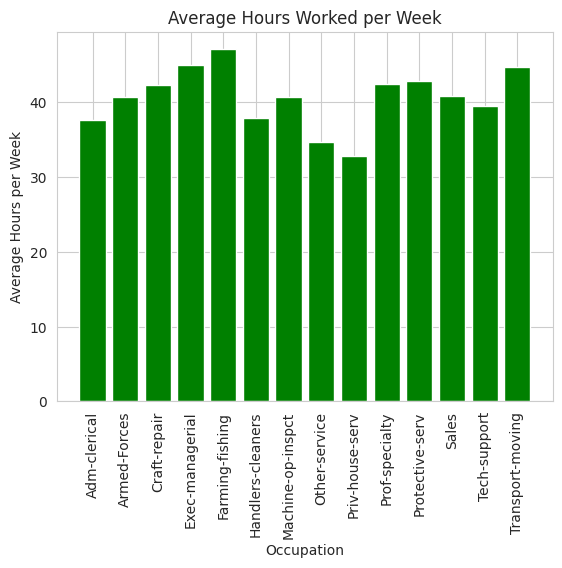

In [26]:
avg_hours = df.groupby('occupation')['hours.per.week'].mean()

plt.bar(avg_hours.index, avg_hours.values, color='green')

plt.xlabel('Occupation')
plt.ylabel('Average Hours per Week')
plt.title('Average Hours Worked per Week')

plt.xticks(rotation=90)

plt.show()

## Task 2: Count Plot

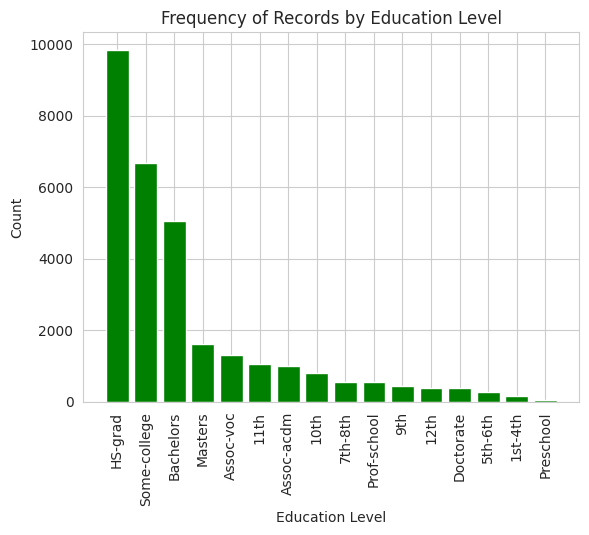

education
HS-grad         9840
Some-college    6678
Bachelors       5044
Masters         1627
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          557
Prof-school      542
9th              455
12th             377
Doctorate        375
5th-6th          288
1st-4th          151
Preschool         45
Name: count, dtype: int64


In [25]:
education_count = df['education'].value_counts()

plt.bar(education_count.index, education_count.values, color='green')

plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Frequency of Records by Education Level')

plt.xticks(rotation=90)
plt.show()

print(education_count)

## Task 3: Histogram — Distribution Shape


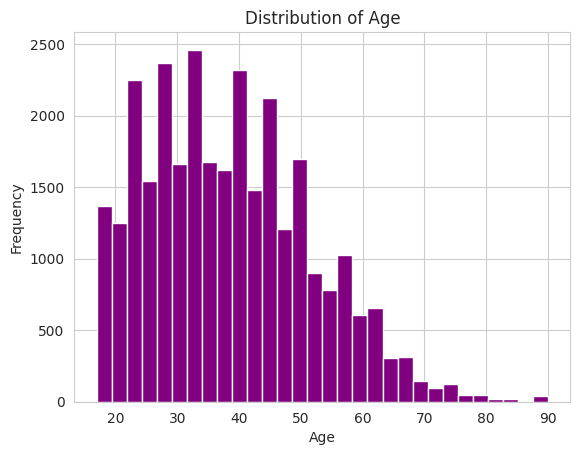

Skewness: 0.530227781834009
count    30162.000000
mean        38.437902
std         13.134665
min         17.000000
25%         28.000000
50%         37.000000
75%         47.000000
max         90.000000
Name: age, dtype: float64


In [27]:
plt.hist(df['age'], bins=30, color='purple')

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')

plt.show()

print("Skewness:", df['age'].skew())
print(df['age'].describe())

## Task 4: Box Plot —

/tmp/ipykernel_4743/3156221123.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([male, female], labels=['Male', 'Female'])


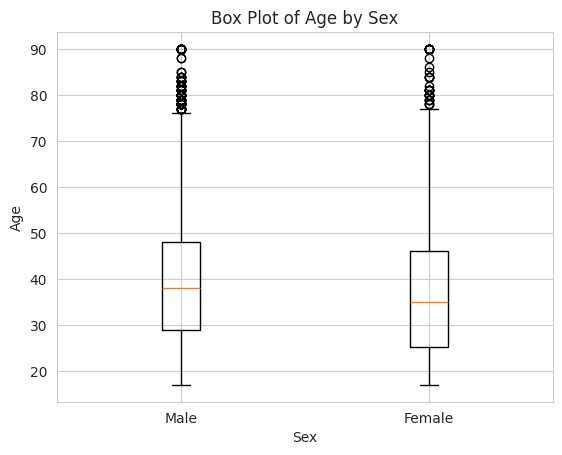

In [31]:
male = df[df['sex'] == 'Male']['age']
female = df[df['sex'] == 'Female']['age']

plt.boxplot([male, female], labels=['Male', 'Female'])

plt.xlabel('Sex')
plt.ylabel('Age')
plt.title('Box Plot of Age by Sex')

plt.show()

## Task 5: Outlier Detection — (IQR)


In [29]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['age'] < lower) | (df['age'] > upper)]
print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Lower bound = {lower}, Upper bound = {upper}")
print("Number of IQR outliers:", len(outliers))

Q1 = 28.0, Q3 = 47.0, IQR = 19.0
Lower bound = -0.5, Upper bound = 75.5
Number of IQR outliers: 169


## Task 6: Outlier Detection — Z-score Comparison


In [18]:
df['zscore'] = stats.zscore(df['age'])
outliers_z = df[df['zscore'].abs() > 3]
print("Number of Z-score outliers:", len(outliers_z))

Number of Z-score outliers: 120


## Task 7: Scatter Plot — Relationship Between Two Variables


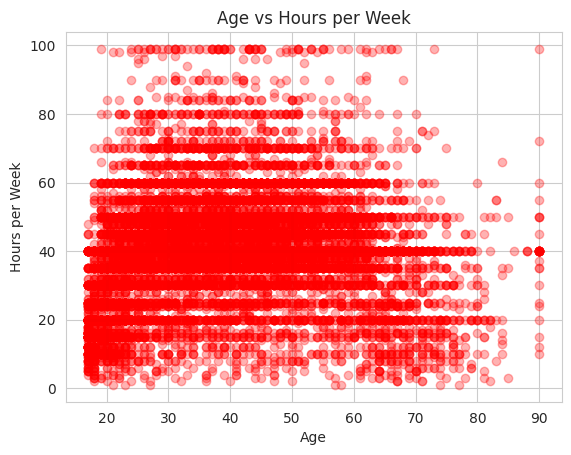

Correlation: 0.10159875929548419


In [34]:
plt.scatter(df['age'], df['hours.per.week'], color='red', alpha=0.3)
plt.xlabel('Age')
plt.ylabel('Hours per Week')
plt.title('Age vs Hours per Week')
plt.show()
print("Correlation:", df['age'].corr(df['hours.per.week']))

task 08

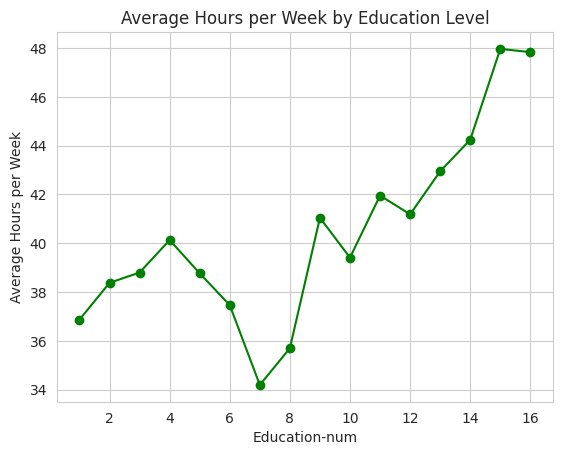

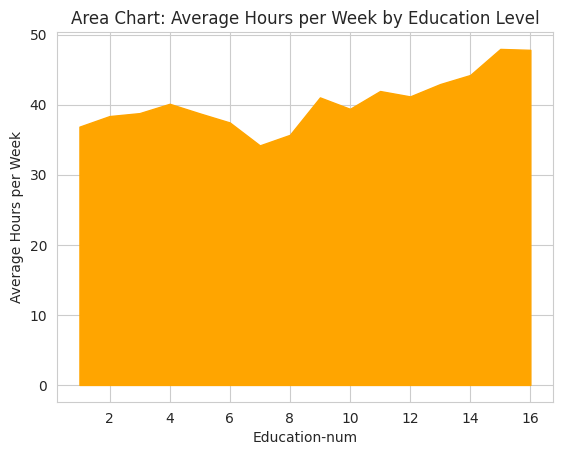

education.num
1     36.866667
2     38.377483
3     38.798611
4     40.131059
5     38.767033
6     37.464634
7     34.193702
8     35.697613
9     41.042073
10    39.411051
11    41.954093
12    41.184524
13    42.948454
14    44.240934
15    47.963100
16    47.832000
Name: hours.per.week, dtype: float64


In [36]:
avg_by_edunum = df.groupby('education.num')['hours.per.week'].mean().sort_index()
plt.plot(avg_by_edunum.index, avg_by_edunum.values, marker='o', color='green')
plt.xlabel('Education-num')
plt.ylabel('Average Hours per Week')
plt.title('Average Hours per Week by Education Level')
plt.show()

plt.fill_between(avg_by_edunum.index, avg_by_edunum.values, color='orange')
plt.xlabel('Education-num')
plt.ylabel('Average Hours per Week')
plt.title('Area Chart: Average Hours per Week by Education Level')
plt.show()

print(avg_by_edunum)

## Task 9: Graphical Integrity Check


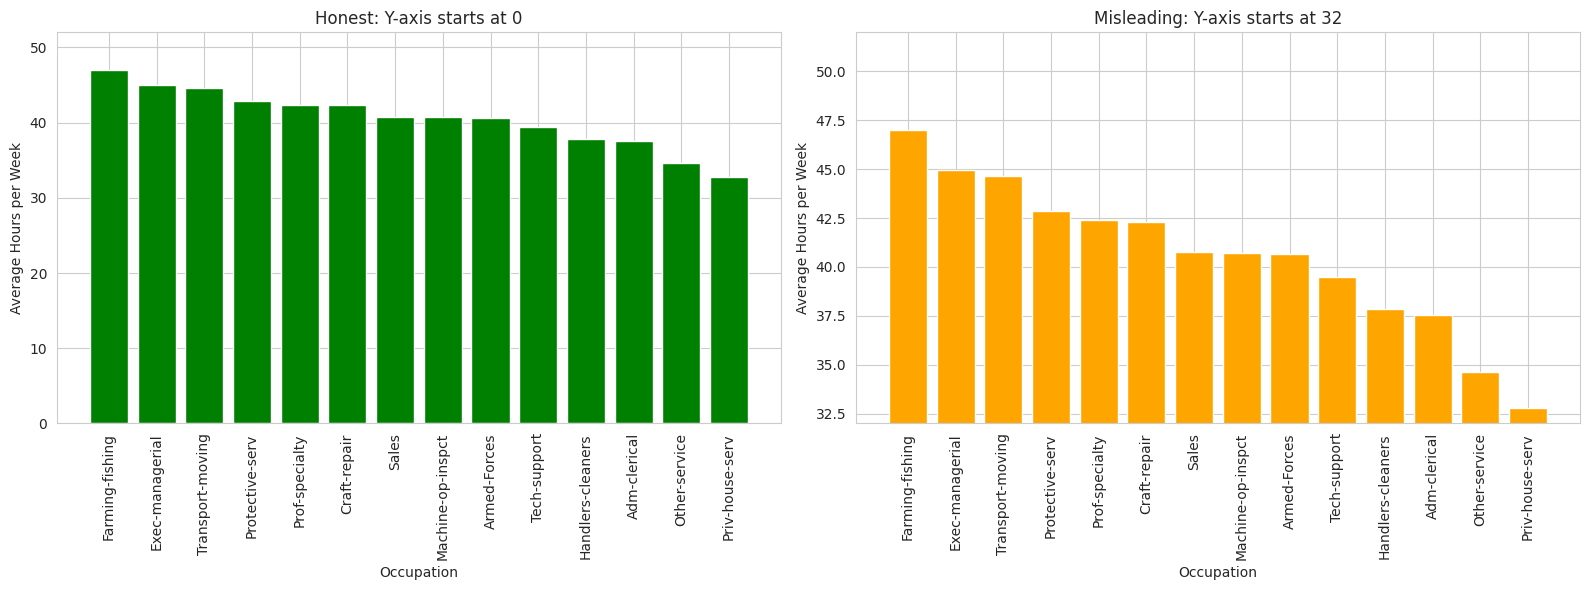

In [37]:
avg_hours = df.groupby('occupation')['hours.per.week'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Honest chart
axes[0].bar(avg_hours.index, avg_hours.values, color='green')
axes[0].set_ylim(0, avg_hours.max() + 5)
axes[0].set_title('Honest: Y-axis starts at 0')
axes[0].set_ylabel('Average Hours per Week')
axes[0].set_xlabel('Occupation')
axes[0].tick_params(axis='x', rotation=90)

# Misleading chart
axes[1].bar(avg_hours.index, avg_hours.values, color='orange')
axes[1].set_ylim(32, avg_hours.max() + 5)
axes[1].set_title('Misleading: Y-axis starts at 32')
axes[1].set_ylabel('Average Hours per Week')
axes[1].set_xlabel('Occupation')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()